# Banana Problem - 3 

Using ResNet50

In [2]:
import os
import urllib.request
import random

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image

from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions

# Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

gpus = tf.config.list_physical_devices('GPU')
print('TensorFlow version:', tf.__version__)
print('Using GPU:', len(gpus) > 0)

TensorFlow version: 2.17.0
Using GPU: False


In [3]:
# Load pretrained TensorFlow ResNet50 (ImageNet)
try:
    model = ResNet50(weights='imagenet', classifier_activation=None)
except TypeError:
    # Fallback for older TensorFlow versions
    model = ResNet50(weights='imagenet')

banana_class_idx = 954

# Decode banana class name from ImageNet mapping
dummy = np.zeros((1, 1000), dtype=np.float32)
dummy[0, banana_class_idx] = 1.0
banana_class_name = decode_predictions(dummy, top=1)[0][0][1]

print('Banana class index:', banana_class_idx)
print('Banana class name :', banana_class_name)

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Banana class index: 954
Banana class name : banana


## Task 1: Vanilla Gradient Saliency Map

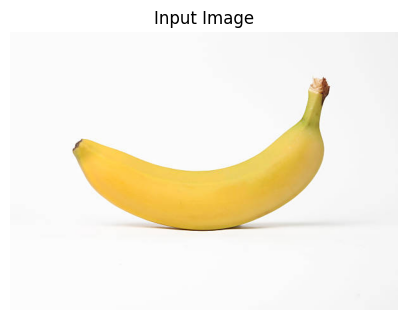

In [4]:
# Load banana image (local file first, then fallback to a public URL).
# You can place your own image as 'banana.jpg' in the same folder as this notebook.
local_image_path = 'banana.jpg'
fallback_url = 'https://upload.wikimedia.org/wikipedia/commons/8/8a/Banana-Single.jpg'
download_path = 'banana_downloaded.jpg'

if os.path.exists(local_image_path):
    image_path = local_image_path
else:
    if not os.path.exists(download_path):
        urllib.request.urlretrieve(fallback_url, download_path)
    image_path = download_path

image = Image.open(image_path).convert('RGB')
plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis('off')
plt.title('Input Image')
plt.show()

In [5]:
# Compute Vanilla Gradient saliency map (TensorFlow)
image_resized = image.resize((224, 224))
img_array = np.array(image_resized).astype(np.float32)
input_batch = np.expand_dims(img_array, axis=0)

input_var = tf.Variable(input_batch)

with tf.GradientTape() as tape:
    processed = preprocess_input(input_var)
    logits = model(processed, training=False)
    banana_score = logits[:, banana_class_idx]

grads = tape.gradient(banana_score, input_var)

# Channel-wise max absolute gradient -> saliency
saliency = tf.reduce_max(tf.abs(grads), axis=-1)[0]

# Normalize to [0,1] for display
saliency = (saliency - tf.reduce_min(saliency)) / (tf.reduce_max(saliency) - tf.reduce_min(saliency) + 1e-8)
saliency_np = saliency.numpy()

# Predicted class for reference
probs = tf.nn.softmax(logits, axis=-1).numpy()
pred_idx = int(np.argmax(probs[0]))
top1 = decode_predictions(probs, top=1)[0][0]

print('Top-1 predicted class:', top1[1], f'(idx={pred_idx})')
print('Banana class score   :', float(banana_score.numpy()[0]))

Top-1 predicted class: banana (idx=954)
Banana class score   : 11.511728286743164


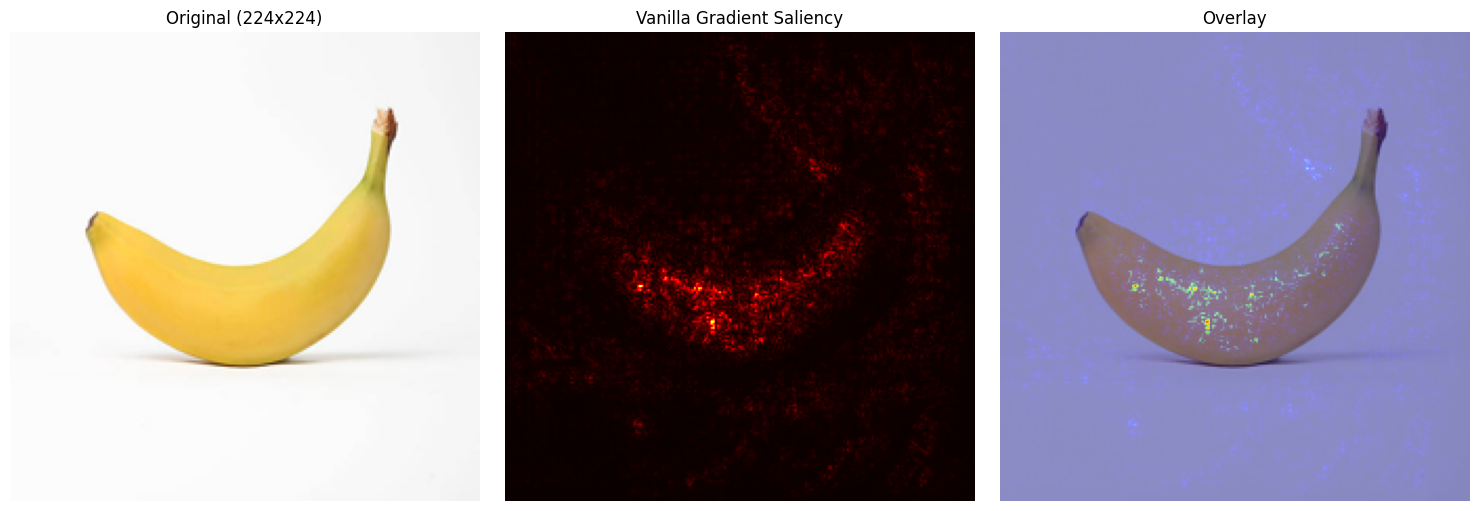

In [6]:
# Visualize saliency
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(image_resized)
ax[0].set_title('Original (224x224)')
ax[0].axis('off')

ax[1].imshow(saliency_np, cmap='hot')
ax[1].set_title('Vanilla Gradient Saliency')
ax[1].axis('off')

ax[2].imshow(image_resized)
ax[2].imshow(saliency_np, cmap='jet', alpha=0.45)
ax[2].set_title('Overlay')
ax[2].axis('off')

plt.tight_layout()
plt.show()

## Task 2: Smooth Visualization via Activation Maximization

In [7]:
# Activation Maximization for banana class (TensorFlow)
steps = 350
lr = 6.0
tv_weight = 2e-3
l2_weight = 1e-6
smooth_every = 20

# Start from random noise in [0, 255]
synth = tf.Variable(tf.random.uniform((1, 224, 224, 3), minval=0.0, maxval=255.0, dtype=tf.float32))
optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

score_history = []

for step in range(steps):
    with tf.GradientTape() as tape:
        processed = preprocess_input(synth)
        logits = model(processed, training=False)
        target_score = logits[:, banana_class_idx]

        # Regularization for smoother, more interpretable patterns
        tv_loss = tf.reduce_mean(tf.image.total_variation(synth))
        l2_loss = tf.reduce_mean(tf.square(synth))

        loss = -target_score + tv_weight * tv_loss + l2_weight * l2_loss

    grads = tape.gradient(loss, synth)
    optimizer.apply_gradients([(grads, synth)])

    synth.assign(tf.clip_by_value(synth, 0.0, 255.0))
    if (step + 1) % smooth_every == 0:
        synth.assign(tf.nn.avg_pool2d(synth, ksize=3, strides=1, padding='SAME'))

    score_history.append(float(target_score.numpy()[0]))

    if (step + 1) % 50 == 0:
        print(f'Step {step + 1:3d}/{steps} | Banana score: {score_history[-1]:.3f}')

Step  50/350 | Banana score: 17.298
Step 100/350 | Banana score: 71.446
Step 150/350 | Banana score: 93.396
Step 200/350 | Banana score: 105.739
Step 250/350 | Banana score: 117.922
Step 300/350 | Banana score: 124.447
Step 350/350 | Banana score: 127.097


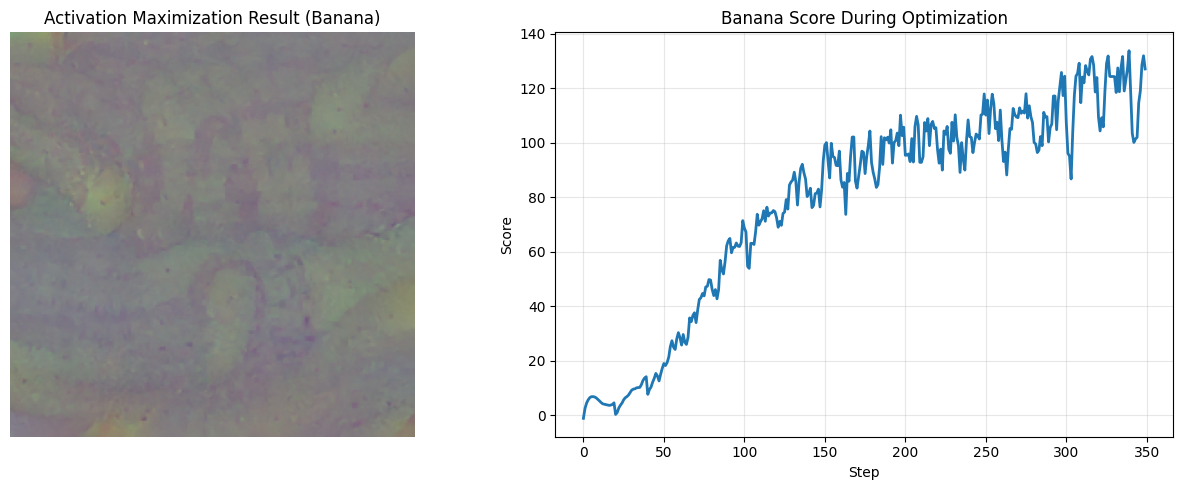

In [8]:
# Visualize generated activation-maximizing image and score trajectory
generated = synth.numpy()[0] / 255.0
generated = np.clip(generated, 0.0, 1.0)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].imshow(generated)
ax[0].set_title('Activation Maximization Result (Banana)')
ax[0].axis('off')

ax[1].plot(score_history, linewidth=2)
ax[1].set_title('Banana Score During Optimization')
ax[1].set_xlabel('Step')
ax[1].set_ylabel('Score')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()